### Calibration of pressure sensor with temperature compensation 🌡️

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from pathlib import Path
import sys
try:
    from ruamel.yaml import YAML
    yaml = YAML()
    yaml.indent(mapping=2, sequence=4, offset=2)
    # yaml.explicit_start=False
except ImportError:
    import yaml
# from scipy.optimize import curve_fit
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

In [ ]:
# Load probe mean values of recorded voltage, V and temperature, °C:
path_in = Path(
    rf"D:\WorkData\_experiment\P~TC\230425@ip1-3_(recalc_250928)\_raw\stand\vsz(txt, range=12h)\230502_0847@ip03-to_fit-x_values.tsv"
)

u, t = np.loadtxt(path_in, skiprows=1, dtype=("f8",) * 2, delimiter="\t", unpack=True)
pid = path_in.name.split("@", 1)[1].split("-", 1)[0]
print(f"Loaded data from probe ID {pid=}")

In [3]:
# Real pressure, dBar, that was possible to apply
ref_possible = np.float64([0, 1, 1.5]) * 10.1971621297793  # dBar

# Atmospheric pressure, dBar:
y_a_in_order = np.float64([1011.6, 1012.7, 1014.0, 1014.2]) / 100


ref_possible, y_a_in_order

(array([ 0.        , 10.19716213, 15.29574319]),
 array([10.116, 10.127, 10.14 , 10.142]))

In [4]:
# Find when each atmospheric pressure was applied
y_a = np.repeat(y_a_in_order, u.size / y_a_in_order.size)

# Standard atmosphere (we calibrate relative to this reference), dBar
y_0 = 1013.25 / 100

y_a, y_0

(array([10.116, 10.116, 10.116, 10.127, 10.127, 10.127, 10.14 , 10.14 ,
        10.14 , 10.142, 10.142, 10.142]),
 10.1325)

In [5]:
# Find when each real pressure was applied
i_exp = np.int8([
    np.argmin(abs(ref_possible - u_cur))
    for u_cur in np.min(ref_possible)
    + (np.max(ref_possible) - np.min(ref_possible)) * (u - np.min(u)) / (np.max(u) - np.min(u))
])
y_dif = ref_possible[i_exp].flatten()
y = y_dif + y_a - y_0

data = pd.DataFrame.from_dict({"iPdif": i_exp, "Pdif": y_dif, "Pa": y_a, "u": u, "t": t, "P": y})
print(
    "iPdif - index of possible pressure differences applied,\n"
    "Pdif - Applied pressure difference; Pa - atmospheric, dBar;\n"
    f"P - Real pressure relative to Standard atmosphere {y_0} dBar;\n"
    "u - pressure PCB output voltage, V; t - temperature, °C\n",
    data,
)
x = data[['u', 't']]
print(f'Samples x features {tuple(x.columns)} size: {x.shape}')

iPdif - index of possible pressure differences applied,
Pdif - Applied pressure difference; Pa - atmospheric, dBar;
P - Real pressure relative to Standard atmosphere 10.1325 dBar;
u - pressure PCB output voltage, V; t - temperature, °C
     iPdif       Pdif      Pa            u       t          P
0       0   0.000000  10.116  1634702.958   3.401  -0.016500
1       1  10.197162  10.116  3225373.200   3.359  10.180662
2       2  15.295743  10.116  4014984.371   3.340  15.279243
3       0   0.000000  10.127  1629954.940   4.491  -0.005500
4       1  10.197162  10.127  3209693.693   4.547  10.191662
5       2  15.295743  10.127  3996052.714   4.560  15.290243
6       0   0.000000  10.140  1598584.086  15.009   0.007500
7       1  10.197162  10.140  3137279.800  15.124  10.204662
8       2  15.295743  10.140  3913191.889  15.242  15.303243
9       0   0.000000  10.142  1561664.829  26.994   0.009500
10      1  10.197162  10.142  3074758.412  27.049  10.206662
11      2  15.295743  10.142  3

In [ ]:
#Define our polynomial model, with whatever degree we want
degrees = [1, 2]
for degree in degrees:
    # PolynomialFeatures will create a new matrix consisting of all polynomial combinations
    # of the features with a degree less than or equal to the degree we just gave the model (2)
    poly_model = PolynomialFeatures(degree=degree, include_bias=False)

    # Transform out polynomial features
    poly_x = poly_model.fit_transform(x)
    # For degree=2 should be in the form [1, a, b, a^2, ab, b^2]
    # print(f'initial values {x[0]} mapped to:\n{poly_x[0]}')
    coef_cols = poly_model.get_feature_names_out()

    # Fit the model
    regr = LinearRegression()    # we use linear regression as a base!!! ** sometimes misunderstood **
    regr.fit(poly_x, y)

    y_pred = regr.predict(poly_x)
    print(f'Fitted polynom of degree {degree}: ', end='')
    str_poly = (' + '.join([f'{regr.intercept_:.6g}'] + [
        f"{coef:.6g} * {name.replace(' ', ' * ')}" for coef, name in zip(regr.coef_, poly_model.get_feature_names_out())]
    )).replace('+ -', '- ')
    mse = root_mean_squared_error(y, y_pred)
    str_out = f'p = {str_poly}\nMean squared error: {mse:.3g}'

    if degree == degrees[-1]:
        print('We use it below.')
    print(str_out)

path_out = Path(path_in.parent / f'coefs_{pd.Timestamp.now():%y%m%d}.yaml')
try:
    with path_out.open('r') as f:
        data = yaml.load(f, yaml.SafeLoader)
        try:
            data_pid = data.pop(pid)
        except KeyError:
            data_pid = {}
    if not data:
        data = data_pid = {}
except FileNotFoundError:
    data = data_pid = {}
with path_out.open("w") as f:
    yaml.dump(
        {
            **data,
            pid: {
            **data_pid,
            f"{next(p.split('@', 1)[0] for p in reversed(path_in.parts) if p[:6].isdigit())}": {
                    "poly": str_poly.replace("^", "**"),
                    "mse": round(float(mse), 5),
                    "processed": pd.Timestamp.now().round("h").to_pydatetime(),
                }
            }
        },
        f,
    )

Fitted polynom of degree 1: p = -11.0377 + 6.56307e-06 * u + 0.0396058 * t
Mean squared error: 0.138
Fitted polynom of degree 2: We use it below.
p = -10.4281 + 6.29102e-06 * u + 0.00228416 * t + 1.68405e-14 * u^2 + 1.49235e-08 * u * t - 0.000182423 * t^2
Mean squared error: 0.025


u(min,max): 1.56e+06, 4.01e+06; t(min,max): 3.34, 27.1; P(min,max): -0.0165, 15.3
Errors of fit for experiments with different pressure and temperature:
0.0 dBar: [-0.00603009  0.00790747 -0.01546186  0.01417279] dBar
10.2 dBar: [-0.02467099  0.02954901  0.02934851 -0.03736485] dBar
15.3 dBar: [-0.02825386  0.03155995 -0.02711135  0.02635529] dBar


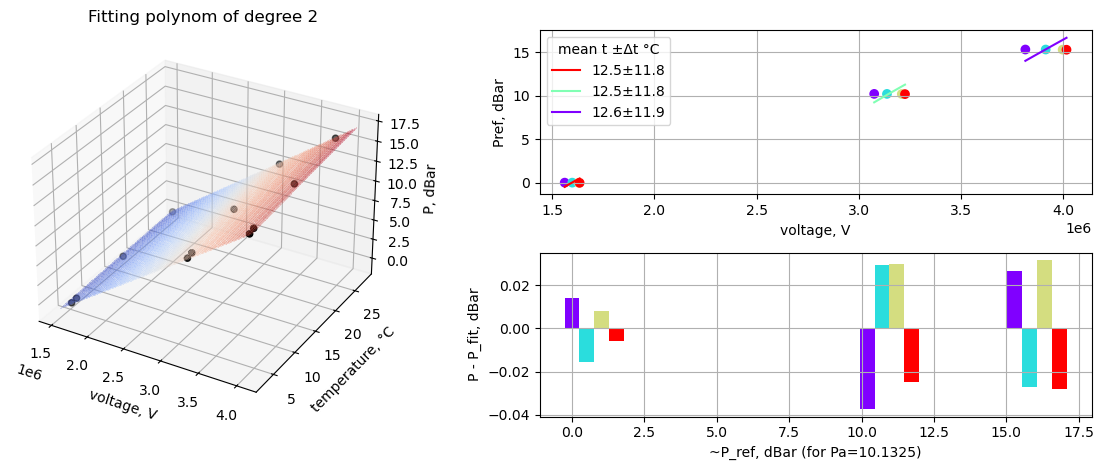

In [8]:
# Show plots
# %matplotlib inline  # is it realy changes something in juputerlab
fig = plt.figure(figsize=plt.figaspect(0.4))
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 4)  # , sharex=ax2 link x axis
ax1 = fig.add_subplot(1, 2, 1, projection="3d")

# Plot result surface
u_min, u_max, t_min, t_max, P_min, P_max = np.min(u), np.max(u), np.min(t), np.max(t), np.min(y), np.max(y)
print(
    "; ".join(
        f"{var}(min,max): {v1:.3g}, {v2:.3g}"
        for var, v1, v2 in (("u", u_min, u_max), ("t", t_min, t_max), ("P", P_min, P_max))
    )
)
ptp_u, ptp_t, ptp_y = u_max - u_min, t_max - t_min, P_max - P_min
n = 50
X = np.linspace(u_min - ptp_u / n, u_max + ptp_u / n, n)
Y = np.linspace(t_min - ptp_t / n, t_max + ptp_t / n, n)
X, Y = np.meshgrid(X, Y)
Z_in = np.column_stack((X.ravel(), Y.ravel()))
Z = regr.predict(poly_model.fit_transform(Z_in)).reshape(X.shape)
surf = ax1.plot_surface(X, Y, Z, cmap=cm.coolwarm, linewidth=0, antialiased=False, alpha=0.2)
ax1.scatter3D(*x.values.T, y, color="k")
ax1.set_xlabel("voltage, V")
ax1.set_ylabel("temperature, °C")
ax1.set_zlabel("P, dBar")  # pressure
ax1.set_title(f"Fitting polynom of degree {degree}")

# Plot predictions lines for each sub experiment in assumption that external values changes linear between fitting points
# experiment's colors
n_exp = max(i_exp) + 1
c_experiments = cm.rainbow(np.linspace(0, 1, n_exp)[::-1])  # reverse colors if last temp lower
shifts_temps = np.linspace(0, 1, int(round(i_exp.size / n_exp)))
c_temps = cm.rainbow(shifts_temps)[np.argsort(t[i_exp == 0])]
# fitting points
isort = np.argsort(
    i_exp + 0.5 * (t_min - t) / ptp_t
)  # Get y order. # addition has no effect if t sorted rev.
ax2.scatter(x["u"].values[isort], y[isort], c=np.tile(c_temps, (n_exp, 1)))  # c_temps[i_exp]
# predictions
print("Errors of fit for experiments with different pressure and temperature:")
scale_bar_width = 1 / 30
for i, (c_exp, y_dif_cur) in enumerate(zip(c_experiments, ref_possible)):
    b_exp = i_exp == i  # each t, °C for current Pdif
    x_exp = x[b_exp]
    y_exp = y[b_exp]
    # print(u_exp, t_exp)
    u_min, t_min, u_max, t_max, t_mean = *x_exp.min(), *x_exp.max(), x_exp["t"].mean()
    # print('u(min,max):', u_min, u_max, 't(min,max):', t_min, t_max)
    X = np.linspace(u_min, u_max, n)
    Y = np.linspace(t_min, t_max, n)
    Z_in = np.column_stack((X, Y))
    Z_in_tr = poly_model.fit_transform(Z_in)
    Z = regr.predict(Z_in_tr)
    Z_check = regr.intercept_ + (regr.coef_ * Z_in_tr).sum(axis=1)
    np.testing.assert_array_almost_equal(Z, Z_check)

    ax2.plot(X, Z, color=c_exp, label=f"{t_mean:.1f}±{(t_max - t_min) / 2:.1f}")
    z_diff = (y - y_pred)[b_exp]  # z_diff = y_exp - regr.predict(poly_model.fit_transform(x_exp))
    print(f"{y_dif_cur:.1f} dBar:", z_diff, "dBar")

# Plot residuals


ax3.bar(
    x=y_dif[isort] + np.tile(shifts_temps, n_exp) * ptp_y * scale_bar_width * n_exp,  # / n_exp
    height=(y - y_pred)[isort],
    width=ptp_y * scale_bar_width,
    color=c_temps,  # np.repeat(c_temps, n_exp, axis=0),  # , label=param
)

# # ax3.plot([u_min, u_max], z_diff, color=c_exp)
# ax3.bar(x=[u_min, u_max], height=z_diff, width=ptp_u/10, color=c_exp)
ax3.set_xlabel(f"~P_ref, dBar (for Pa={y_0})")
ax3.set_ylabel("P - P_fit, dBar")

ax2.set_xlabel("voltage, V")
ax2.set_ylabel("Pref, dBar")
ax2.legend(title="mean t ±Δt °C")
ax2.grid()
ax3.grid()

plt.tight_layout()
plt.savefig(Path(path_in.parent / f"regression_residuals@{pid}.png"))
plt.show()